In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [3]:

df = pd.read_csv(r"C:\Users\Lenovo_owner\OneDrive\Documents\AI_Developer_Toolkit\JUPITER\4_dsa_mentor\racipe_dataset.csv")

df.head()

df.info()

df.isnull().sum()

df["Features"] = (
    df["Cuisine"] + " " +
    df["Diet"] + " " +
    df["MainIngredient"] + " " +
    df["Difficulty"]
)


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Recipe          200 non-null    str  
 1   Cuisine         200 non-null    str  
 2   Diet            200 non-null    str  
 3   MainIngredient  200 non-null    str  
 4   CookingTime     200 non-null    int64
 5   Difficulty      200 non-null    str  
dtypes: int64(1), str(5)
memory usage: 9.5 KB


In [4]:

vectorizer = TfidfVectorizer()

feature_vectors = vectorizer.fit_transform(df["Features"])

similarity = cosine_similarity(feature_vectors)


In [6]:

def recommend(recipe_name):

    recipe_name = recipe_name.lower()

    recipes = df["Recipe"].str.lower()

    if recipe_name not in recipes.values:

        print("Recipe not found")

        return

    index = recipes[recipes == recipe_name].index[0]

    distances = list(enumerate(similarity[index]))

    distances = sorted(distances,key=lambda x:x[1],reverse=True)

    print("Recommended Recipes:\n")

    for i in distances[1:6]:

        print(df.iloc[i[0]]["Recipe"])

recommend("Paneer Butter Masala")


Recommended Recipes:

Palak Paneer
Kadai Paneer
Shahi Paneer
Matar Paneer
Paneer Tikka


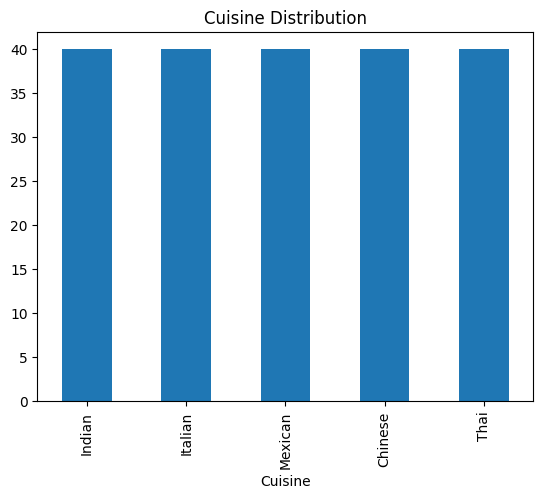

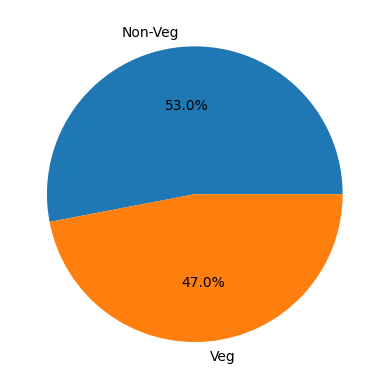

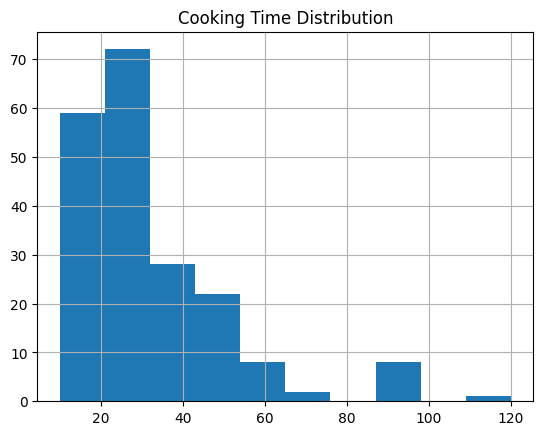

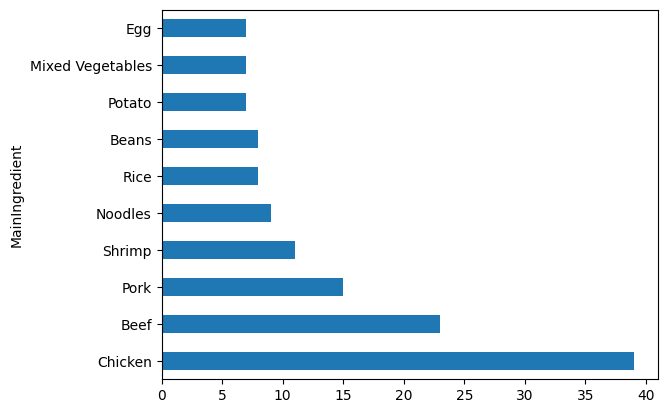

In [7]:

#📊 Visualizations

#Cuisine Distribution

df["Cuisine"].value_counts().plot(kind="bar")

plt.title("Cuisine Distribution")

plt.show()

#Diet Distribution

df["Diet"].value_counts().plot(kind="pie",autopct="%1.1f%%")

plt.ylabel("")

plt.show()

#Cooking Time

df["CookingTime"].hist()

plt.title("Cooking Time Distribution")

plt.show()

#Top Ingredients

df["MainIngredient"].value_counts().head(10).plot(kind="barh")

plt.show()
